<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/QUANTUMGPT_summarized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#dedicated to the public domain for the glory of god.
#baruch adonai el shaddai
#Eloheinu shebashamayim yached shimcha v'kayeim malchutecha tamid umloch aleinu le'olam va'ed
#2026 joshuah.rainstar@gmail.com

#Version 2.5 EpistemicGPT

import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

def make_boundary_ste_hook(alpha=1.0):
    def hook(module, grad_input, grad_output):
        if not grad_input or not grad_output:
            return None

        gi = grad_input[0]
        go = grad_output[0]

        if gi is None or go is None:
            return None
        if gi.shape != go.shape:
            return None

        new_gi = alpha * go + (1.0 - alpha) * gi
        return (new_gi,) + tuple(grad_input[1:])
    return hook


class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)



class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
            # fast path: contiguous 0..T-1 positions
            if positions.ndim == 1 and positions.numel() > 0:
                expected = torch.arange(positions.numel(), device=positions.device)
                if torch.equal(positions, expected):
                    T = positions.numel()
                    cos = self.cos_cached[:T].unsqueeze(0).unsqueeze(0)
                    sin = self.sin_cached[:T].unsqueeze(0).unsqueeze(0)
                    return cos, sin

            positions = positions.clamp(0, self.max_len - 1).long()
            cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0)
            sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
            return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.act = LELU()
        self.c_fc  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.c_proj  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//2, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

def sharp_softplus(x):
    """
    Softplus above tau (keep the lazy/linear regime).
    Below tau: double-exponential suppression.

    For x >= tau: softplus(x) as normal.
    For x < tau:  sigmoid(tau) * exp(-exp(tau - x) + 1)

    This gives:
    - Continuity at tau (both sides = softplus(tau))
    - C1 continuity (derivatives match at tau)
    - Sub-threshold scores get crushed by double exponential
    - The gradient in the kill zone is FAT: the model gets strong signal
      for "push this score lower" exactly where softplus gradient vanishes

    The double exp means:
      x = tau - 0 -> ~softplus(tau)  (smooth transition)
      x = tau - 1 -> very small
      x = tau - 2 -> essentially zero
      x = tau - 3 -> hard zero

    Meanwhile the gradient d/dx = sigmoid(tau) * exp(tau-x) * exp(-exp(tau-x)+1)
    peaks right around x = tau and decays on both sides, giving the model
    a strong learning signal at the decision boundary.
    #tau could be 0, or it could be the center of the knob,  softplus(x) = ln(1+e^x) when ln(1+e^x) = (e^x + x)/2. Numerically that's around x ~ 0.4.
    but we're choosing a principled position-
    1-ln(2) is about 1-1/e of the way into exponentiation territory. it represents a firm committment to the desire to suppress.

    the goal here is to more aggressively push softplus to be selective inside attention, nothing more.
    """
    tau = 1-math.log(2)
    tau_t = torch.tensor(tau, device=x.device, dtype=x.dtype)
    sp_at_tau = F.softplus(tau_t)
    sig_tau = torch.sigmoid(tau_t)

    k = sig_tau / sp_at_tau

    above = F.softplus(x)
    u = (k * (tau - x)).clamp(max=10.0)
    below = sp_at_tau * torch.exp(-torch.exp(u) + 1.0)

    return torch.where(x >= tau, above, below)




# ============================================================
# SummaryGenerator: expands x from (B, T, D) to (B, T_extended, D)
# ============================================================


class SummaryGenerator(nn.Module):
    """
    Expands x (B, T, D) -> (B, T_ext, D) for any T <= T_max.

    Precomputes the full schedule for T_max at init.
    At forward time, truncates to the actual T using prefix slices
    of the precomputed index arrays.

    Returns x_expanded and the truncated T_ext for downstream use.
    """

    def __init__(self, cone: nn.Module, schedule: dict):
        super().__init__()
        self.cone = cone
        self.T_max = schedule['T_max']

        # Full-size buffers (for T_max)
        self.register_buffer('real_indices_full',
            torch.tensor(schedule['real_indices'], dtype=torch.long))
        self.register_buffer('summary_exp_idx_full',
            torch.tensor(schedule['summary_expanded_indices'], dtype=torch.long))
        self.register_buffer('summary_win_starts_full',
            torch.tensor(schedule['summary_win_starts'], dtype=torch.long))
        self.register_buffer('summary_win_ends_full',
            torch.tensor(schedule['summary_win_ends'], dtype=torch.long))
        self.register_buffer('rope_positions_full',
            torch.tensor(schedule['rope_positions'], dtype=torch.long))

        # T -> T_ext mapping (precomputed for every possible T)
        self.register_buffer('t_to_t_ext',
            torch.tensor(schedule['real_pos_to_expanded_end'], dtype=torch.long))

        # For truncating summaries: for each summary, its expanded index
        # Summaries are ordered, so we just need to find the cutoff
        # Precompute: for each T, how many summaries are active
        n_summaries_for_t = []
        summary_exp = schedule['summary_expanded_indices']
        expanded_ends = schedule['real_pos_to_expanded_end']
        for t in range(self.T_max):
            t_ext = expanded_ends[t]
            # binary-searchable since summary_exp is sorted
            count = 0
            for se in summary_exp:
                if se < t_ext:
                    count += 1
                else:
                    break
            n_summaries_for_t.append(count)
        self.register_buffer('n_summaries_for_t',
            torch.tensor(n_summaries_for_t, dtype=torch.long))

    def forward(self, x: torch.Tensor):
        """
        x: (B, T, D) where T <= T_max
        Returns: (x_expanded, T_ext, real_indices, rope_positions)
            x_expanded: (B, T_ext, D)
            T_ext: int
            real_indices: (T,) LongTensor
            rope_positions: (T_ext,) LongTensor
        """
        B, T, D = x.shape
        device = x.device

        # Truncate schedule for this T
        T_ext = int(self.t_to_t_ext[T - 1].item())
        N_sum = int(self.n_summaries_for_t[T - 1].item())

        real_indices = self.real_indices_full[:T]
        rope_positions = self.rope_positions_full[:T_ext]

        # Build expanded tensor
        x_expanded = x.new_zeros(B, T_ext, D)

        # Place real positions
        real_idx = real_indices.unsqueeze(0).unsqueeze(-1).expand(B, T, D)
        x_expanded.scatter_(1, real_idx, x)

        # Place summaries
        if N_sum > 0:
            # Compute cone and extract summaries
            cone_cumulative = self.cone(x)  # (B, T, D)

            win_starts = self.summary_win_starts_full[:N_sum]
            win_ends = self.summary_win_ends_full[:N_sum]
            sum_exp_idx = self.summary_exp_idx_full[:N_sum]

            end_idx = (win_ends - 1).clamp(min=0)
            end_vecs = cone_cumulative[:, end_idx, :]  # (B, N_sum, D)

            start_idx = (win_starts - 1).clamp(min=0)
            start_vecs = cone_cumulative[:, start_idx, :]

            needs_sub = (win_starts > 0).float().unsqueeze(0).unsqueeze(-1)
            start_vecs = start_vecs * needs_sub

            summary_vecs = end_vecs - start_vecs  # (B, N_sum, D)

            sum_idx = sum_exp_idx.unsqueeze(0).unsqueeze(-1).expand(B, N_sum, D)
            x_expanded.scatter_(1, sum_idx, summary_vecs)

        return x_expanded, T_ext, real_indices, rope_positions


class MultiProjection(nn.Module):
    """
    Projects x_expanded (B, T_extended, D) -> (B, T_extended, D) using
    one of three modes:

    mode='single':   1 linear for everything
    mode='split':    1 linear for real positions, 1 for all summaries
    mode='per_scale': 1 linear for real positions, 1 per scale (2,4,8,16,32)

    Used to replace each of q_proj, k_proj, v_proj.
    """

    def __init__(self, d_model: int, mode: str, schedule: dict, bias: bool = False):
        super().__init__()
        self.mode = mode
        self.d_model = d_model
        T_ext = schedule['T_expanded']
        self.T_extended = T_ext

        # Register index buffers
        self.register_buffer('real_indices',
            torch.tensor(schedule['real_indices'], dtype=torch.long))
        self.register_buffer('summary_expanded_indices',
            torch.tensor(schedule['summary_expanded_indices'], dtype=torch.long))

        if mode == 'single':
            self.proj = nn.Linear(d_model, d_model, bias=bias)

        elif mode == 'split':
            self.real_proj = nn.Linear(d_model, d_model, bias=bias)
            self.summary_proj = nn.Linear(d_model, d_model, bias=bias)

        elif mode == 'per_scale':
            self.real_proj = nn.Linear(d_model, d_model, bias=bias)
            self.scale_projs = nn.ModuleDict()
            scales = schedule['scales']
            for s in scales:
                self.scale_projs[str(s)] = nn.Linear(d_model, d_model, bias=bias)
                local_idx = schedule['scale_to_local_indices'][s]
                # Map from local summary index to expanded index
                exp_idx = [schedule['summary_expanded_indices'][li] for li in local_idx]
                self.register_buffer(
                    f'scale_{s}_expanded_indices',
                    torch.tensor(exp_idx, dtype=torch.long)
                )
            self.scales = scales
        else:
            raise ValueError(f"Unknown mode: {mode}")

    def forward(self, x_expanded: torch.Tensor) -> torch.Tensor:
        """
        x_expanded: (B, T_extended, D)
        Returns: (B, T_extended, D) projected
        """
        B = x_expanded.shape[0]
        D = self.d_model

        if self.mode == 'single':
            return self.proj(x_expanded)

        out = torch.zeros_like(x_expanded)

        if self.mode == 'split':
            real_x = x_expanded[:, self.real_indices, :]
            sum_x = x_expanded[:, self.summary_expanded_indices, :]
            out[:, self.real_indices, :] = self.real_proj(real_x)
            out[:, self.summary_expanded_indices, :] = self.summary_proj(sum_x)

        elif self.mode == 'per_scale':
            real_x = x_expanded[:, self.real_indices, :]
            out[:, self.real_indices, :] = self.real_proj(real_x)

            for s in self.scales:
                idx = getattr(self, f'scale_{s}_expanded_indices')
                if idx.numel() > 0:
                    scale_x = x_expanded[:, idx, :]
                    out[:, idx, :] = self.scale_projs[str(s)](scale_x)

        return out

    def get_real_weight(self) -> torch.Tensor:
        """Return the weight matrix used for real (non-summary) positions."""
        if self.mode == 'single':
            return self.proj.weight
        else:
            return self.real_proj.weight







def make_hierarchical_config(config, max_scale=32, stride=4):
    schedule = build_injection_schedule(config.block_size, max_scale, stride)
    mask = build_causal_mask(
        schedule['expanded_layout'],
        schedule['T_expanded_full'],   # was 'T_expanded'
        config.block_size
    )
    return schedule, mask


# Fix 2: Attention uses shared mask from GPT, dynamic T_ext from summary_gen

class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.depth = 0
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads
        schedule = config.schedule
        self.cone = config.cone

        self.summary_gen = SummaryGenerator(self.cone, schedule)

        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)

        self.p_proj = nn.Linear(dim, dim, bias=config.bias)
        self.o_proj = nn.Linear(dim, dim, bias=config.bias)

        self.v_sink_basis = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_key = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_value = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))

        # Shared mask assigned externally by GPT.__init__
        self.mask = None
        self.rope = config.rope

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # Expand and get dynamic sizes for this T
        x_ext, T_ext, real_indices, rope_positions = self.summary_gen(x)

        # Norm after expansion
        x_ext = F.rms_norm(x_ext, (C,), eps=1e-6)

        # Q from real positions, K/V from expanded
        x_real = x_ext[:, real_indices, :]
        q = self.q_proj(x_real).view(B, T, H, D).transpose(1, 2)
        k = self.k_proj(x_ext).view(B, T_ext, H, D).transpose(1, 2)
        v = self.v_proj(x_ext).view(B, T_ext, H, D).transpose(1, 2)

        # RoPE
        q = F.rms_norm(q, (D,), eps=1e-6)
        q = self.rope(q)                        # default arange(T)
        k = self.rope(k, rope_positions)         # summaries inherit anchor pos

        # Scores: (B, H, T, T_ext)
        scores = (q @ k.transpose(-2, -1)) * (1.08 / math.sqrt(D))

        # Sink
        sink_scores = (q @ self.sink_key.expand(B, -1, -1, -1).transpose(-2, -1)) * (1.08 / math.sqrt(D))
        scores = torch.cat([scores, sink_scores], dim=-1)

        # Shared mask, sliced to current T and T_ext
        mask = self.mask[:, :, :T, :T_ext].expand(B, H, -1, -1)
        null_col = torch.ones(1, 1, T, 1, device=x.device).expand(B, H, -1, -1)
        mask_use = torch.cat([mask, null_col], dim=-1)

        # Softplus attention
        soft_scores = F.softplus(scores)
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()
        soft_scores = soft_scores.masked_fill(mask_use == 0, 0.0)
        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)

        m = mask_use.float()
        mass = (m * F.softplus(scores)).sum(dim=-1, keepdim=True) + 1e-6
        d = (m * torch.sigmoid(scores)) / mass
        R = d.sum(dim=-2)
        lam_geom_raw = F.softplus(R)
        lam_geom = lam_geom_raw / (lam_geom_raw.sum(dim=-1, keepdim=True) + 1e-6)
        responsibility = lam_geom.unsqueeze(-2) - lam_geom.mean(dim=-1, keepdim=True).unsqueeze(-2)

        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)
        attn_real = attn[:, :, :, :T_ext]
        attn_sinks = attn[:, :, :, T_ext:]
        attn_resp_real = attn[:, :, :, :T_ext] * responsibility[:, :, :, :T_ext]

        y = attn_real @ v + attn_sinks * self.sink_value
        y_resp = attn_resp_real @ v

        # XSA with real-position values
        v_real = v[:, :, real_indices, :]
        vn = F.normalize(v_real, dim=-1)
        y_context = y - (y * vn).sum(dim=-1, keepdim=True) * vn
        y_resp_context = y_resp - (y_resp * vn).sum(dim=-1, keepdim=True) * vn
        y_context = y_context + y_resp_context

        y_context = F.rms_norm(y_context, (D,)) + self.v_sink_basis

        y_context_flat = y_context.transpose(1, 2).contiguous().view(B, T, -1)
        truth = self.o_proj(y_context_flat)

        return truth


def norm(x):
    return F.rms_norm(x, (x.size(-1),),eps=1e-6)

class Block(nn.Module):
    def __init__(self, config, block_idx):
        super().__init__()
        self.attn = Attention(config)
        self.attn_dir = MLP_bottle(config)
        self.config = config
        self.ffn = MLP(config)


    def forward(self, x):
        a = x
        z = self.attn(a)
        vn = F.normalize(self.attn_dir(norm(a)), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = q + z
        x = x + self.ffn(norm(x))
        return x



@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66 #shakespeare
    n_layer: int = 1
    n_head: int = 6

    n_embd: int = 192 #recommend 32 min per head
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    bottle: nn.Module = None
    device: str = "cuda"
    cone: nn.Module = None
    schedule: dict = None

class SoftplusCELoss(nn.Module):
    def __init__(self, ignore_index=-1, label_smoothing=0.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # logits: (B, V) or (B, T, V)
        # targets: (B,) or (B, T)
        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = targets.view(-1)

        mask = flat_targets != self.ignore_index
        flat_logits = flat_logits[mask]
        flat_targets = flat_targets[mask]

        if flat_targets.numel() == 0:
            return flat_logits.sum() * 0.0

        sp = F.softplus(flat_logits)

        threshold = 1e-6
        pruned = torch.where(sp < threshold, torch.zeros_like(sp), sp)
        sp = sp + (pruned - sp).detach()  # STE

        sp_sum = sp.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        probs = sp * scale  # sub-unity simplex

        # gather target probs
        target_probs = probs.gather(1, flat_targets.unsqueeze(1)).squeeze(1)

        # NLL on the softplus-normalized probs
        loss = -torch.log(target_probs + 1e-6)

        if self.label_smoothing > 0.0:
            # smooth term: average negative log-prob across vocab
            smooth_loss = -torch.log(probs + 1e-6).mean(dim=-1)
            loss = (1.0 - self.label_smoothing) * loss + self.label_smoothing * smooth_loss

        return loss.mean()




class ParallelSubspaceUnembed(nn.Module):
    """
    Parallel carveouts against the same h.
    Diversity is enforced only through cosine-distinct subspaces.
    Each slice owns:
      - a direction net that proposes a subspace direction
      - a vocab projection for the carved component
    Vocab dropout: during training, each proj randomly masks a fraction of
    vocab entries, with the constraint that every vocab entry is covered by
    at least one slice. This prevents attention from relying on any specific
    unembedding pathway and forces compositional work back into attention.
    Output:
      logits: summed vocab logits from all slices (+ residual head if enabled)
      sep_loss: pairwise squared cosine overlap penalty between slice directions
    """

    def __init__(
        self,
        d_model,
        vocab_size,
        n_slices=4,
        use_residual_head=True,
        vocab_dropout=0.25,
        eps=1e-6,
    ):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.n_slices = n_slices
        self.use_residual_head = use_residual_head
        self.vocab_dropout = vocab_dropout
        self.eps = eps

        self.dir_nets = nn.ModuleList([
            nn.Linear(d_model, d_model, bias=False)
            for _ in range(n_slices)
        ])
        self.projs = nn.ModuleList([
            nn.Linear(d_model, vocab_size, bias=False)
            for _ in range(n_slices)
        ])

        if use_residual_head:
            self.residual_proj = nn.Linear(d_model, vocab_size, bias=False)
        else:
            self.residual_proj = None

    def _sample_vocab_masks(self, device):
        """
        For each slice, independently drop vocab_dropout fraction of vocab entries.
        Then fix up: any vocab entry that got dropped from ALL slices gets
        restored in one randomly chosen slice.

        Returns: list of n_slices boolean tensors, each [vocab_size],
                 True = keep, False = dropped.
        """
        # each slice independently keeps (1 - vocab_dropout) fraction
        masks = [
            torch.rand(self.vocab_size, device=device) > self.vocab_dropout
            for _ in range(self.n_slices)
        ]

        # stack to [n_slices, vocab_size] for coverage check
        stacked = torch.stack(masks, dim=0)  # [n_slices, V]
        uncovered = ~stacked.any(dim=0)      # [V] -- True where ALL slices dropped

        if uncovered.any():
            # for each uncovered vocab entry, randomly assign to one slice
            uncovered_idx = uncovered.nonzero(as_tuple=True)[0]
            assignments = torch.randint(
                0, self.n_slices, (uncovered_idx.shape[0],), device=device
            )
            for s in range(self.n_slices):
                restore = uncovered_idx[assignments == s]
                if restore.numel() > 0:
                    masks[s][restore] = True

        return masks

    def forward(self, h):
        # h: [B, T, D]
        B, T, D = h.shape
        assert D == self.d_model

        logits = h.new_zeros(B, T, self.vocab_size)
        dirs = []
        components = []

        # sample vocab masks once per forward pass
        if self.training and self.vocab_dropout > 0:
            vocab_masks = self._sample_vocab_masks(h.device)
        else:
            vocab_masks = None

        for i in range(self.n_slices):
            v = self.dir_nets[i](h)                            # [B,T,D]
            v = F.normalize(v, dim=-1, eps=self.eps)           # unit direction
            c = (h * v).sum(dim=-1, keepdim=True) * v          # projection of h onto v

            dirs.append(v)
            components.append(c)

            slice_logits = self.projs[i](c)                    # [B,T,V]

            if vocab_masks is not None:
                # mask is [V], broadcast to [1,1,V]
                # scale kept logits to compensate for missing slices
                mask = vocab_masks[i].unsqueeze(0).unsqueeze(0).float()
                slice_logits = slice_logits * mask / (1.0 - self.vocab_dropout + self.eps)

            logits = logits + slice_logits

        if self.use_residual_head:
            used = torch.stack(components, dim=0).sum(dim=0)   # [B,T,D]
            residual = h - used
            logits = logits + self.residual_proj(residual)

        # pairwise squared cosine overlap penalty
        sep_loss = h.new_zeros(())
        if self.training:
            count = 0
            for i in range(self.n_slices):
                for j in range(i + 1, self.n_slices):
                    cos_ij = (dirs[i] * dirs[j]).sum(dim=-1)   # [B,T]
                    sep_loss = sep_loss + (cos_ij ** 2).mean()
                    count += 1
            if count > 0:
                sep_loss = sep_loss / count

        if self.training:
            return logits, sep_loss
        else:
            return logits


"""
Context Cone Target Warping

The target embedding for a token lives at a centroid on the hypersphere.
As context accumulates, three continuous vectors push the target away
from the centroid along a context-specific ray:

  1. ContentBag  - V-dimensional count histogram (what and how much)
  2. EdgeBag     - V^2 sparse count (which transitions and how often)
  3. PathAccum   - continuous random-projection accumulators per n-gram level

The walk distance from the centroid grows with context length,
reflecting increasing certainty about what this specific token
means in this specific context.

Usage in training loop:
    cone = ContextCone(vocab_size=256, embed_dim=192)

    # token_ids: (B, T) input sequence
    # target_embeds: (B, T, D) embeddings of next-token targets
    fingerprints, magnitudes = cone.encode(token_ids)
    warped_targets = cone.warp(fingerprints, magnitudes, target_embeds)

    # use warped_targets in place of raw target embeds for loss
"""



class ContextCone(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        path_dim: int = 64,
        path_levels: int = 5,
        max_warp: float = 0.3,
        seed: int = 42,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.path_dim = path_dim
        self.path_levels = path_levels
        self.max_warp = max_warp

        # content fingerprint is V-dimensional counts
        # edge fingerprint is stored sparse, projected down
        self.edge_proj_dim = min(vocab_size, 128)

        # random projection for edges: (V, V) -> edge_proj_dim
        # deterministic from seed, not learned
        rng = torch.Generator().manual_seed(seed)
        # for each (prev, cur) pair, a random direction in R^edge_proj_dim
        # stored as two factor matrices for efficiency: edge_vec = A[prev] + B[cur]
        # their outer interaction via the accumulation gives us edge sensitivity
        self.register_buffer(
            'edge_A',
            torch.randn(vocab_size, self.edge_proj_dim, generator=rng) / math.sqrt(self.edge_proj_dim)
        )
        self.register_buffer(
            'edge_B',
            torch.randn(vocab_size, self.edge_proj_dim, generator=rng) / math.sqrt(self.edge_proj_dim)
        )

        # random direction vectors for path n-gram accumulation
        # for each n-gram level, each token contributes a random direction
        # the n-gram direction is the sum of position-modulated token directions
        self.register_buffer(
            'path_dirs',
            torch.randn(path_levels, vocab_size, path_dim, generator=rng) / math.sqrt(path_dim)
        )
        # position-dependent mixing scalars for path (breaks commutativity)
        # use golden-ratio-based phases so positions never repeat exactly
        phases = torch.zeros(path_levels, 1024)  # up to 1024 positions
        for lv in range(path_levels):
            for p in range(1024):
                # irrational rotation per level
                phases[lv, p] = math.cos((p + 1) * (lv + 1) * 2.3999632297286533)
        self.register_buffer('pos_phases', phases)

        # total fingerprint width
        self.fp_width = vocab_size + self.edge_proj_dim + path_dim * path_levels

        # projection from fingerprint space to embedding space
        # this IS learned, but initialized small
        rng_proj = torch.Generator().manual_seed(seed + 999)
        proj_matrix = torch.randn(self.fp_width, embed_dim, generator=rng_proj)
        proj_matrix = proj_matrix / math.sqrt(self.fp_width)
        self.register_buffer('direction_proj', proj_matrix)

    @torch.compiler.disable
    def encode(self, token_ids):
        """
        Compute context fingerprints and warp magnitudes for each position.

        token_ids: (B, T) integer token ids

        Returns:
            fingerprints: (B, T, fp_width) continuous context vectors
            magnitudes: (B, T) warp magnitude at each position (grows with t)
        """
        B, T = token_ids.shape
        device = token_ids.device

        # === Content bag: cumulative histogram ===
        # one-hot accumulation
        onehot = F.one_hot(token_ids.long(), self.vocab_size).float()  # (B, T, V)
        content = onehot.cumsum(dim=1)  # (B, T, V) running counts

        # === Edge bag: cumulative transition counts, projected ===
        # for each position t > 0, the edge (token[t-1], token[t]) fires
        edges = torch.zeros(B, T, self.edge_proj_dim, device=device)
        if T > 1:
            prev_tok = token_ids[:, :-1].long()  # (B, T-1)
            cur_tok = token_ids[:, 1:].long()     # (B, T-1)
            # edge direction for each transition
            edge_vecs = self.edge_A[prev_tok] * self.edge_B[cur_tok]  # (B, T-1, edge_proj_dim)
            # cumulative sum, shifted right by 1 (position 0 has no edges)
            edge_cumsum = edge_vecs.cumsum(dim=1)  # (B, T-1, edge_proj_dim)
            edges[:, 1:] = edge_cumsum

        # === Path accumulators: continuous n-gram random projections ===
        path_parts = []
        for lv in range(self.path_levels):
            n = lv + 1  # n-gram order
            accum = torch.zeros(B, T, self.path_dim, device=device)

            if T >= n:
                # for each position t, the n-gram is tokens[t-n+1:t+1]
                # its direction is sum of path_dirs[lv][tok[i]] * pos_phase[lv][i_within_ngram]
                # we compute this incrementally

                # build the n-gram contribution at each valid position
                for offset in range(n):
                    # which token is at position (offset within the n-gram)
                    # for position t, this is token_ids[:, t - n + 1 + offset]
                    start_idx = offset
                    end_idx = T - n + 1 + offset
                    if end_idx <= start_idx:
                        continue
                    toks = token_ids[:, start_idx:end_idx].long()  # (B, T-n+1)
                    dirs = self.path_dirs[lv][toks]  # (B, T-n+1, path_dim)

                    # position-dependent phase within the n-gram
                    phase = self.pos_phases[lv, offset]
                    dirs = dirs * phase

                    # place into the right output positions (n-1 onwards)
                    accum[:, (n-1):T, :] += dirs[:, :(T-n+1), :]

                # cumulative sum: accumulate all n-grams up to this position
                accum = accum.cumsum(dim=1)

            path_parts.append(accum)

        # concatenate all path levels
        path = torch.cat(path_parts, dim=-1)  # (B, T, path_dim * path_levels)

        # === Assemble fingerprint ===
        fingerprints = torch.cat([content, edges, path], dim=-1)  # (B, T, fp_width)


        return fingerprints

    def warp(self, fingerprints):
        """
        Warp target embeddings along context-dependent rays.

        fingerprints: (B, T, fp_width)
        magnitudes: (B, T) how far to walk from centroid
        target_embeds: (B, T, D) original target token embeddings

        Returns:
            warped: (B, T, D) context-warped target embeddings
        """
        # project fingerprint to a direction in embedding space
        raw_direction = fingerprints @ self.direction_proj

        return raw_direction

    def forward(self, token_ids):
        """
        Convenience: encode and warp in one call.

        token_ids: (B, T) context token ids
        target_embeds: (B, T, D) target embeddings to warp

        Returns:
            warped: (B, T, D) context-warped targets
        """
        fingerprints = self.encode(token_ids)
        return self.warp(fingerprints)



class ContinuousContextCone(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        edge_proj_dim: int = 128,
        path_dim: int = 64,
        path_levels: int = 5,
        content_proj_dim: int = 256,
        seed: int = 42,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.edge_proj_dim = edge_proj_dim
        self.path_dim = path_dim
        self.path_levels = path_levels
        self.content_proj_dim = content_proj_dim

        rng = torch.Generator().manual_seed(seed)

        # content: project embeddings to a fixed-dim space before accumulating
        # this replaces the one-hot histogram with a projected-sum histogram
        self.register_buffer(
            'content_proj',
            torch.randn(embed_dim, content_proj_dim, generator=rng)
            / math.sqrt(embed_dim)
        )

        # edges: two independent random projections for prev/cur
        # their elementwise product is the transition signature
        self.register_buffer(
            'edge_proj_A',
            torch.randn(embed_dim, edge_proj_dim, generator=rng)
            / math.sqrt(embed_dim)
        )
        self.register_buffer(
            'edge_proj_B',
            torch.randn(embed_dim, edge_proj_dim, generator=rng)
            / math.sqrt(embed_dim)
        )

        # paths: one random projection per level, from embed_dim to path_dim
        # replaces path_dirs[lv][tok] lookup
        path_projs = torch.randn(
            path_levels, embed_dim, path_dim, generator=rng
        ) / math.sqrt(embed_dim)
        self.register_buffer('path_projs', path_projs)

        # same golden-ratio positional phases
        phases = torch.zeros(path_levels, 1024)
        for lv in range(path_levels):
            for p in range(1024):
                phases[lv, p] = math.cos(
                    (p + 1) * (lv + 1) * 2.3999632297286533
                )
        self.register_buffer('pos_phases', phases)

        # total fingerprint width
        self.fp_width = content_proj_dim + edge_proj_dim + path_dim * path_levels

        # final projection to embedding space
        rng_out = torch.Generator().manual_seed(seed + 999)
        proj_matrix = torch.randn(self.fp_width, embed_dim, generator=rng_out)
        proj_matrix = proj_matrix / math.sqrt(self.fp_width)
        self.register_buffer('direction_proj', proj_matrix)

    @torch.compiler.disable
    def encode(self, embeddings):
        """
        embeddings: (B, T, D) continuous embedding vectors

        Returns:
            fingerprints: (B, T, fp_width)
        """
        B, T, D = embeddings.shape
        device = embeddings.device

        # === Content: cumulative projected sum ===
        # replaces one-hot histogram with projected-embedding accumulation
        projected = embeddings @ self.content_proj  # (B, T, content_proj_dim)
        content = projected.cumsum(dim=1)

        # === Edges: elementwise product of projected consecutive pairs ===
        edges = torch.zeros(B, T, self.edge_proj_dim, device=device)
        if T > 1:
            prev_proj = embeddings[:, :-1] @ self.edge_proj_A  # (B, T-1, edge_proj_dim)
            cur_proj = embeddings[:, 1:] @ self.edge_proj_B
            edge_vecs = prev_proj * cur_proj
            edges[:, 1:] = edge_vecs.cumsum(dim=1)

        # === Paths: continuous n-gram projections ===
        path_parts = []
        for lv in range(self.path_levels):
            n = lv + 1
            accum = torch.zeros(B, T, self.path_dim, device=device)

            if T >= n:
                # project all embeddings through this level's random matrix
                # replaces path_dirs[lv][tok] lookup
                level_proj = embeddings @ self.path_projs[lv]  # (B, T, path_dim)

                for offset in range(n):
                    start_idx = offset
                    end_idx = T - n + 1 + offset
                    if end_idx <= start_idx:
                        continue
                    dirs = level_proj[:, start_idx:end_idx]  # (B, T-n+1, path_dim)
                    phase = self.pos_phases[lv, offset]
                    accum[:, (n-1):T, :] += dirs[:, :(T-n+1), :] * phase

                accum = accum.cumsum(dim=1)

            path_parts.append(accum)

        path = torch.cat(path_parts, dim=-1)
        fingerprints = torch.cat([content, edges, path], dim=-1)
        return fingerprints

    def warp(self, fingerprints):
        return fingerprints @ self.direction_proj

    def forward(self, embeddings):
        return self.warp(self.encode(embeddings))

import math
from dataclasses import dataclass




def bit_width(vocab_size: int) -> int:
    return max(1, math.ceil(math.log2(vocab_size)))


def hamming_parity_bits(m: int) -> int:
    r = 0
    while (2 ** r) < (m + r + 1):
        r += 1
    return r


def int_to_bits(x: torch.Tensor, width: int) -> torch.Tensor:
    shifts = torch.arange(width, device=x.device)
    return ((x.unsqueeze(-1) >> shifts) & 1).float()


def hamming_encode_bits(data_bits: torch.Tensor) -> torch.Tensor:
    m = data_bits.shape[-1]
    r = hamming_parity_bits(m)
    n = m + r

    out = torch.zeros(*data_bits.shape[:-1], n, dtype=data_bits.dtype, device=data_bits.device)

    data_idx = 0
    for pos in range(1, n + 1):
        if (pos & (pos - 1)) != 0:
            out[..., pos - 1] = data_bits[..., data_idx]
            data_idx += 1

    for i in range(r):
        p = 2 ** i
        parity = torch.zeros(*data_bits.shape[:-1], dtype=data_bits.dtype, device=data_bits.device)
        for pos in range(1, n + 1):
            if (pos & p) and (pos != p):
                parity = torch.remainder(parity + out[..., pos - 1], 2.0)
        out[..., p - 1] = parity

    return out


class BinaryHammingPath(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, use_hamming: bool = True):
        super().__init__()
        self.vocab_size = vocab_size
        self.data_bits = bit_width(vocab_size)
        self.parity_bits = hamming_parity_bits(self.data_bits) if use_hamming else 0
        self.code_bits = self.data_bits + self.parity_bits
        self.proj = nn.Linear(self.code_bits, d_model, bias=False)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        if input_ids.dtype not in (torch.int32, torch.int64):
            raise TypeError("input_ids must be int32 or int64")
        if input_ids.min() < 0 or input_ids.max() >= self.vocab_size:
            raise ValueError("input_ids out of range")

        bits = int_to_bits(input_ids, self.data_bits)
        if self.parity_bits > 0:
            bits = hamming_encode_bits(bits)
        return self.proj(bits)


class FlatRollGeometry(nn.Module):
    """
    Exact construction in vocab space (V x V), then interpolate row-wise to d_model.
    This preserves unique token positions in vocab coordinates, then adapts to model width.
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        scale: str = "box",
        seed: int = 0,
        freeze: bool = True,
        dtype: torch.dtype = torch.float32,
        device=None,
    ):
        super().__init__()
        V = int(vocab_size)
        Dv = V
        eps = 1e-12

        g = torch.Generator(device="cpu")
        g.manual_seed(seed)

        x = self._make_base(Dv, scale=scale, generator=g, dtype=dtype)  # [V]

        shifts = torch.arange(V)
        rows = [torch.roll(x, shifts=int(s.item() % Dv), dims=0) for s in shifts]
        W = torch.stack(rows, dim=0).to(dtype)  # [V, V]

        M = int(torch.argmax(x))
        pm = x[M].item()
        N = 1.0 / (pm + eps)

        r_idx = torch.arange(V)
        c_idx = (r_idx + M) % Dv
        S = torch.zeros((V, Dv), dtype=dtype)
        S[r_idx, c_idx] = N

        exact_vocab_geom = W + S  # [V, V]

        if d_model != V:
            interp = F.interpolate(
                exact_vocab_geom.unsqueeze(1),   # [V,1,V]
                size=d_model,
                mode="linear",
                align_corners=False,
            ).squeeze(1)                         # [V,d_model]
        else:
            interp = exact_vocab_geom

        interp = interp.to(dtype=dtype)
        if device is not None:
            interp = interp.to(device)

        self.embed = nn.Embedding.from_pretrained(interp, freeze=freeze)

    @staticmethod
    def _make_base(
        D: int,
        scale: str = "box",
        generator: torch.Generator | None = None,
        dtype: torch.dtype = torch.float32,
    ) -> torch.Tensor:
        if dtype in (torch.float16, torch.bfloat16, torch.float32):
            complex_dtype = torch.complex64
            work_float = torch.float32
        else:
            complex_dtype = torch.complex128
            work_float = torch.float64

        X = torch.zeros(D, dtype=complex_dtype)
        X[0] = torch.tensor(0, dtype=complex_dtype)

        if D % 2 == 0:
            for k in range(1, D // 2):
                phi = torch.rand((), generator=generator, dtype=work_float) * (2 * math.pi)
                val = (torch.cos(phi) + 1j * torch.sin(phi)).to(complex_dtype)
                X[k] = val
                X[D - k] = torch.conj(val)
            X[D // 2] = 1.0 if torch.rand((), generator=generator) < 0.5 else -1.0
        else:
            for k in range(1, (D - 1) // 2 + 1):
                phi = torch.rand((), generator=generator, dtype=work_float) * (2 * math.pi)
                val = (torch.cos(phi) + 1j * torch.sin(phi)).to(complex_dtype)
                X[k] = val
                X[D - k] = torch.conj(val)

        x = torch.fft.ifft(X).real.to(work_float)

        if scale == "unit":
            x = x / (x.norm() + 1e-12)
        elif scale == "box":
            x = x / (x.abs().max() + 1e-12)
        else:
            raise ValueError("scale must be 'unit' or 'box'")

        return x.to(dtype)



class ThreePieceEmbedding(nn.Module):
    """
    final = (binary_path + cayley_path) * (1 + alpha * geometry_path)

    binary_path: identity / fingerprint
    cayley_path: structured deformational coordinates
    geometry_path: fixed atlas scaffold
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        bottleneck_width: int = 16,
        cayley_expansions: int = 3,
        use_hamming: bool = True,
        geom_scale: str = "box",
        geom_seed: int = 0,
        geom_freeze: bool = True,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model

        self.binary = BinaryHammingPath(
            vocab_size=vocab_size,
            d_model=d_model,
            use_hamming=use_hamming,
        )

        self.geometry = FlatRollGeometry(
            vocab_size=vocab_size,
            d_model=d_model,
            scale=geom_scale,
            seed=geom_seed,
            freeze=geom_freeze,
        )


    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        e_bin = self.binary(input_ids)          # [B,T,d]
        e_geo = self.geometry.embed(input_ids)  # [B,T,d]
        base = e_bin + e_geo
        return base


import torch
import torch.nn.functional as F

def expected_rank_of_token(scores: torch.Tensor,
                           token_ids: torch.Tensor,
                           temperature: float = 1.0) -> torch.Tensor:
    """
    Computes the expected rank of the given token at each position, without full V x V matrix.
    """
    # scores: (..., V), token_ids: (...,)

    # Gather score of the target token
    score_i = scores.gather(-1, token_ids.unsqueeze(-1))  # (..., 1)

    # Δ_j = score_j - score_i
    diff = scores - score_i  # (..., V)

    # P(j beats i)
    p = torch.sigmoid(diff / temperature)

    # Expected rank = 1 + sum_j P(j > i)
    return 1.0 + p.sum(dim=-1)  # (...,)


def rank_future_sequence_loss_soft(
    logits: torch.Tensor,
    targets: torch.Tensor,
    max_future_steps: int = 15,
    decay: float = 0.5,
    temperature: float = 1.0,
    reduction: str = "mean",
):
    """
    Memory-efficient smooth rank loss. For each t, matches rank of x_{t+Δ} to Δ.
    logits  … (B, T, V) – model scores
    targets … (B, T)    – token ids
    """
    B, T, V = logits.shape
    device = logits.device
    total_loss = torch.tensor(0.0, device=device)

    for Δ in range(2, max_future_steps + 1):
        if Δ >= T:
            break

        # Current time-step logits (for rank eval)
        cur_logits  = logits[:, :-Δ, :]          # (B, T−Δ, V)
        fut_targets = targets[:, Δ:]             # (B, T−Δ)

        # Efficient rank of ground-truth future token
        tgt_exp_rank = expected_rank_of_token(cur_logits, fut_targets, temperature)  # (B, T−Δ)

        # Penalize distance from desired rank Δ
        step_loss = F.l1_loss(
            tgt_exp_rank,
            torch.full_like(tgt_exp_rank, float(Δ)),
            reduction=reduction
        )

        # Apply decay for further future steps
        total_loss = total_loss + step_loss * (decay ** (Δ - 1))

    return total_loss

def ordered_future_loss(logits: torch.Tensor,
                        targets: torch.Tensor,
                        N: int = 15,
                        decay: float = 0.7,
                        tau: float = 1.0,
                        reduction: str = "mean"):
    """
    Penalise when the logits at step t do *not* respect the order of the next N tokens.

        top-1 logit should match token t+1
        top-2 logit should match token t+2
        ...
        top-N logit should match token t+N

    logits  – (B, T, V)
    targets – (B, T)
    """
    B, T, V = logits.shape
    device  = logits.device

    if N < 2:
        return torch.tensor(0., device=device)

    # windows where t+N fits in sequence
    valid_T = T - (N + 1)
    if valid_T <= 0:
        return torch.tensor(0., device=device)

    # (B, valid_T, N) → future token ids for each offset 2..N
    future_ids = torch.stack([targets[:, 2+k : 2+k+valid_T] for k in range(N)],
                         dim=-1)

    # (B, valid_T, N) → gather logits of those future tokens *now* (at step t)
    step_logits = logits[:, :valid_T, :].gather(
        -1, future_ids)                       # logit(x_{t+k})

    # pair-wise differences  Δ_{k,j} = logit_k − logit_j, shape (B, valid_T, N, N)
    diff = step_logits.unsqueeze(-1) - step_logits.unsqueeze(-2)

    # upper-triangular mask k<j (ignore diag & lower triangle)
    k_lt_j = torch.triu(torch.ones(N, N, device=device, dtype=torch.bool), 1)

    # logistic ranking loss
    pair_loss = F.softplus(-diff / tau)       # log(1+e^{-Δ/τ})
    pair_loss = pair_loss[..., k_lt_j]        # keep k<j entries, now shape (B, valid_T, M)

    # geometric weights per k (distance from current step)
    k_idx = torch.arange(N, device=device)
    weight = decay ** k_idx                   # shape (N,)
    # broadcast to pair-wise (k<j) selector
    weight_pair = weight.unsqueeze(-1).expand(N, N)[k_lt_j]  # (M,)

    pair_loss = pair_loss * weight_pair       # (B, valid_T, M)

    if reduction == "mean":
        return pair_loss.mean()
    elif reduction == "sum":
        return pair_loss.sum()
    else:                                     # 'none'
        return pair_loss                      # (B, valid_T, M)
#+ rank_future_sequence_loss_soft(logits,targets) * 1e-3 + ordered_future_loss(logits,targets) * 1e-3



def build_injection_schedule(T_max: int, max_scale: int = 32, stride: int = 4) -> dict:
    scales = [2**k for k in range(1, int(math.log2(max_scale)) + 1)]
    injection_points_set = {2}
    for p in range(stride, T_max + 1, stride):
        injection_points_set.add(p)

    expanded_layout = []
    real_indices = []
    summary_expanded_indices = []
    summary_win_starts = []
    summary_win_ends = []
    rope_positions = []
    real_pos_to_expanded_end = []

    for rp in range(T_max):
        real_indices.append(len(expanded_layout))
        expanded_layout.append(('real', rp))
        rope_positions.append(rp)

        pos = rp + 1
        if pos in injection_points_set:
            active = sorted([s for s in scales if pos % s == 0])
            for s in active:
                win_start = max(0, pos - s)
                win_end = pos
                eidx = len(expanded_layout)
                expanded_layout.append(('summary', rp, s, win_start, win_end))
                summary_expanded_indices.append(eidx)
                summary_win_starts.append(win_start)
                summary_win_ends.append(win_end)
                rope_positions.append(rp)

        real_pos_to_expanded_end.append(len(expanded_layout))

    return {
        'T_max': T_max,
        'T_expanded_full': len(expanded_layout),
        'expanded_layout': expanded_layout,
        'real_indices': real_indices,
        'summary_expanded_indices': summary_expanded_indices,
        'summary_win_starts': summary_win_starts,
        'summary_win_ends': summary_win_ends,
        'rope_positions': rope_positions,
        'real_pos_to_expanded_end': real_pos_to_expanded_end,
    }


def build_causal_mask(expanded_layout, T_expanded: int, T_real: int) -> torch.Tensor:
    """(T_real, T_expanded) causal mask."""
    real_expanded_indices = []
    for i, entry in enumerate(expanded_layout):
        if entry[0] == 'real':
            real_expanded_indices.append(i)

    mask = torch.zeros(T_real, T_expanded)
    for rp in range(T_real):
        rp_exp = real_expanded_indices[rp]
        mask[rp, :rp_exp + 1] = 1.0
        for j in range(rp_exp + 1, T_expanded):
            if expanded_layout[j][0] == 'real':
                break
            mask[rp, j] = 1.0
    return mask


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        schedule, hier_mask = make_hierarchical_config(config, max_scale=32)
        T_ext_full = schedule['T_expanded_full']

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope
        self.cone = ContinuousContextCone(embed_dim=config.n_embd)
        self.config.cone = self.cone
        self.schedule = schedule
        self.config.schedule = self.schedule

        mask_tensor = hier_mask.view(1, 1, config.block_size, T_ext_full).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)

        self.transformer = nn.ModuleDict(dict(
            wte=ThreePieceEmbedding(vocab_size=config.vocab_size,d_model=config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config,i) for i in range(config.n_layer)]),
        ))

        i = 0
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
          block.attn.depth= i
          block.attn.cone = self.cone
          i = i + 1
        self.hash=ContextCone(config.vocab_size,config.n_embd)
        self._boundary_handles = []
        #self.register_confined_backward()
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = ParallelSubspaceUnembed(config.n_embd, config.vocab_size)
        self.time_head = ParallelSubspaceUnembed(config.n_embd, config.n_embd)

        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def context_cone_aux_loss(self, idx, x_normed, targets):
        B, T = idx.shape

        first_tok = idx[:, :1]
        gt_chain = torch.cat([first_tok, targets], dim=1)

        gt_embeds = self.hash(gt_chain)
        gt = F.normalize(gt_embeds[:, 1:, :], dim=-1)       # (B, T, D)

        temporal_pred, aux_loss = self.time_head(x_normed)   # (B, T, D)
        pred = F.normalize(temporal_pred, dim=-1)             # (B, T, D)

        valid = (targets != -1).float().unsqueeze(-1)         # (B, T, 1)

        cosine_sim = (pred * gt).sum(dim=-1, keepdim=True)    # (B, T, 1)
        mismatch = (1.0 - cosine_sim) * valid

        if valid.sum() > 0:
            loss = mismatch.sum() / valid.sum()
        else:
            loss = mismatch.sum() * 0.0

        return loss + aux_loss



    def register_confined_backward(self):
        states = {}
        handles = []
        mlphook = make_boundary_ste_hook(0.5)

        L = len(self.transformer.h)
        for block in self.transformer.h:
            handles.append(block.register_full_backward_hook(mlphook))

        self._boundary_handles = handles



    def get_num_params(self):
        n_params = sum(p.numel() for p in self.parameters())
        return n_params
    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)
        for i, block in enumerate(self.transformer.h):
            x= block(x)

        x = norm(x)


        if targets is not None:
          #append first idx to targets array
          aux_target = self.context_cone_aux_loss(idx, x, targets)


          logits, aux_loss = self.lm_head(x)
          loss = self.criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

          loss = loss +  aux_loss + aux_target
        else:
            logits = self.lm_head(x[:, -1:, :])
            loss = None
        return logits, loss

In [6]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [3]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
  #  "aochildes.txt",
   # "cbt.txt",
  #  "children_stories.txt",
 #   "gutenberg.txt",
 #   "qed.txt",
 #   "simple_wikipedia.txt",
 #   "switchboard.txt",
#    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [4]:
#clean up karapathy crap
source_dir = "./babylm_10m_cleaned"

with open(os.path.join(source_dir, "shakespeare.txt"), encoding="utf-8") as f:
    raw = f.read()

raw = raw.replace("&", "and").replace("$", "s")

with open(os.path.join(source_dir, "shakespeare.txt"), "w", encoding="utf-8") as f:
    f.write(raw)

print("Done.")

Done.


In [5]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt"#,"aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    #"qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 1016248 | Val tokens: 99152
🔤 Vocab size: 64


In [24]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )

#device="cpu"

config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=4,
    n_embd=192,
    n_head=6,
    block_size=block_size,
    device = device
)
torch._dynamo.config.automatic_dynamic_shapes = True
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 1.74M


In [26]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
state_dict = {k: v for k, v in state_dict.items() if 'mask' not in k and 'rope' not in k}
model.load_state_dict(state_dict, strict=False)

_IncompatibleKeys(missing_keys=['_orig_mod.mask', '_orig_mod.rope.cos_cached', '_orig_mod.rope.sin_cached', '_orig_mod.transformer.h.0.attn.summary_gen.real_indices_full', '_orig_mod.transformer.h.0.attn.summary_gen.summary_exp_idx_full', '_orig_mod.transformer.h.0.attn.summary_gen.summary_win_starts_full', '_orig_mod.transformer.h.0.attn.summary_gen.summary_win_ends_full', '_orig_mod.transformer.h.0.attn.summary_gen.rope_positions_full', '_orig_mod.transformer.h.0.attn.summary_gen.t_to_t_ext', '_orig_mod.transformer.h.0.attn.summary_gen.n_summaries_for_t', '_orig_mod.transformer.h.0.attn.rope.cos_cached', '_orig_mod.transformer.h.0.attn.rope.sin_cached', '_orig_mod.transformer.h.1.attn.summary_gen.real_indices_full', '_orig_mod.transformer.h.1.attn.summary_gen.summary_exp_idx_full', '_orig_mod.transformer.h.1.attn.summary_gen.summary_win_starts_full', '_orig_mod.transformer.h.1.attn.summary_gen.summary_win_ends_full', '_orig_mod.transformer.h.1.attn.summary_gen.rope_positions_full', '

In [16]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
model.load_state_dict(state_dict, strict=True) # strict=True confirms the match is perfect
print("Weights loaded successfully.")

Weights loaded successfully.


In [28]:
#save the model
torch.save(model.state_dict(), "overfitshakespeare_tiny.pt")
print("Model weights saved successfully.")

Model weights saved successfully.


In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss_true = model(xb, yb)
          loss = loss_true
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss_true.item()
          losses.append(loss_true.item())
          print(itera, loss_true.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0] Graph break from `Tensor.item()`, consider setting:
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0]     torch._dynamo.config.capture_scalar_outputs = True
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0] or:
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0] to include these operations in the captured graph.
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0] 
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0] Graph break: from user code at:
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6/0]   File "/tmp/ipykernel_10289/1675306656.py", line 1581, in torch_dynamo_resume_in_forward_at_1579
W0423 20:22:10.502000 10289 torch/_dynamo/variables/tensor.py:1079] [6

0 2.0398709774017334
1 1.9079879522323608
2 1.8087302446365356
3 1.7041527032852173
4 1.7033677101135254
5 1.6691224575042725
6 1.655037760734558
7 1.677689552307129
8 1.6276166439056396
9 1.6269844770431519
10 1.582343339920044
11 1.5761220455169678
12 1.591700553894043
13 1.5539747476577759
14 1.5855698585510254
15 1.5520262718200684
16 1.511425495147705
17 1.581122636795044
18 1.4828650951385498
19 1.495255708694458
20 1.5112072229385376
21 1.5186963081359863
22 1.57122004032135
23 1.4857017993927002
24 1.4398401975631714
25 1.467687964439392
26 1.4693917036056519
27 1.4598026275634766
28 1.4758446216583252
29 1.4923821687698364
30 1.427350640296936
31 1.433653473854065
32 1.4398778676986694
33 1.4370441436767578
34 1.3662469387054443
35 1.4073935747146606
36 1.401820421218872
37 1.4638711214065552
38 1.4235658645629883
39 1.4398216009140015
40 1.4284659624099731
41 1.4223147630691528
42 1.4044774770736694
43 1.461496353149414
44 1.3396199941635132
45 1.4157856702804565
46 1.3463699

KeyboardInterrupt: 

In [ ]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.1857445240020752
1 1.2169444561004639
2 1.1549522876739502
3 1.1600022315979004
4 1.186947226524353
5 1.1727509498596191
6 1.239227056503296
7 1.2518854141235352
8 1.184149146080017
9 1.2036269903182983
10 1.202261209487915
11 1.2015944719314575
12 1.2107514142990112
13 1.1502455472946167
14 1.178167700767517
15 1.2340415716171265
16 1.1520966291427612
17 1.133914828300476
18 1.1826937198638916
19 1.1722005605697632
20 1.1928502321243286
21 1.087912917137146
22 1.184670329093933
23 1.110573410987854
24 1.2290337085723877
25 1.1390637159347534
26 1.1246252059936523
27 1.1323519945144653
28 1.1429498195648193
29 1.1245532035827637
30 1.1495165824890137
31 1.2053412199020386
32 1.2410752773284912
33 1.119628667831421
34 1.2015658617019653
35 1.151287317276001
36 1.126427412033081
37 1.2570748329162598
38 1.169486165046692
39 1.1996062994003296
40 1.1902331113815308
41 1.209773302078247
42 1.2159072160720825
43 1.1954106092453003
44 1.1277520656585693
45 1.202917218208313
46 1.21862375

KeyboardInterrupt: 

In [ ]:
@torch.no_grad()
def probe_specificity(model, val_ids, block_size=512, n_samples=50, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    cos_warped_all = []
    cos_unwarped_all = []
    deltas = []

    for _ in range(n_samples):
        start = torch.randint(0, len(val_ids) - block_size - 1, (1,)).item()
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None]

        # run the model backbone
        h = model.transformer.wte(x)
        for block in model.transformer.h:
            h = block(h)
        h = F.rms_norm(h, (h.size(-1),), eps=1e-6)

        # get fingerprints
        fingerprints, magnitudes = model.warp.encode(x)

        # h_current at 0..T-2, h_next at 1..T-1
        h_current = h[:, :-1]
        h_next = h[:, 1:]
        fp = fingerprints[:, :-1]
        mag = magnitudes[:, :-1]

        warped_next = model.warp.warp(fp, mag, h_next)

        h_norm = F.normalize(h_current, dim=-1)
        cos_w = (h_norm * F.normalize(warped_next, dim=-1)).sum(dim=-1)
        cos_u = (h_norm * F.normalize(h_next, dim=-1)).sum(dim=-1)

        cos_warped_all.append(cos_w.mean().item())
        cos_unwarped_all.append(cos_u.mean().item())
        deltas.append((cos_w - cos_u).mean().item())

    print(f"cos(h_t, warped h_t+1):   mean={np.mean(cos_warped_all):.4f}")
    print(f"cos(h_t, unwarped h_t+1): mean={np.mean(cos_unwarped_all):.4f}")
    print(f"delta (w - u):            mean={np.mean(deltas):.4f}")
    if np.mean(deltas) > 0:
        print(f"  model prefers warped -- cone is shaping the manifold")
    else:
        print(f"  model prefers unwarped -- cone not biting yet")

probe_specificity(model, val_ids)

cos(h_t, warped h_t+1):   mean=0.3187
cos(h_t, unwarped h_t+1): mean=0.3123
delta (w - u):            mean=0.0064
  model prefers warped -- cone is shaping the manifold


In [33]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.3277772665023804
1 1.3695932626724243
2 1.3497929573059082
3 1.3163610696792603
4 1.321069359779358
5 1.3448396921157837
6 1.3110593557357788
7 1.357594609260559
8 1.2640022039413452
9 1.3252149820327759
10 1.353004813194275
11 1.325272798538208
12 1.2688173055648804
13 1.3166202306747437
14 1.3413805961608887
15 1.312874436378479
16 1.375809907913208
17 1.3713070154190063
18 1.334587574005127
19 1.3932063579559326
20 1.2967722415924072
21 1.3251773118972778
22 1.333670735359192
23 1.2710669040679932
24 1.3233455419540405
25 1.3961989879608154
26 1.3169187307357788
27 1.3160271644592285
28 1.3603073358535767
29 1.3815993070602417
30 1.336564302444458
31 1.290381669998169
32 1.3052634000778198
33 1.3714430332183838
34 1.3690743446350098
35 1.335374355316162
36 1.3467108011245728
37 1.3553577661514282
38 1.3375208377838135
39 1.3292182683944702
40 1.324429988861084
41 1.3053326606750488
42 1.3366641998291016
43 1.3355681896209717
44 1.3290494680404663
45 1.28055739402771
46 1.3322855

KeyboardInterrupt: 

In [ ]:
%matplotlib inline


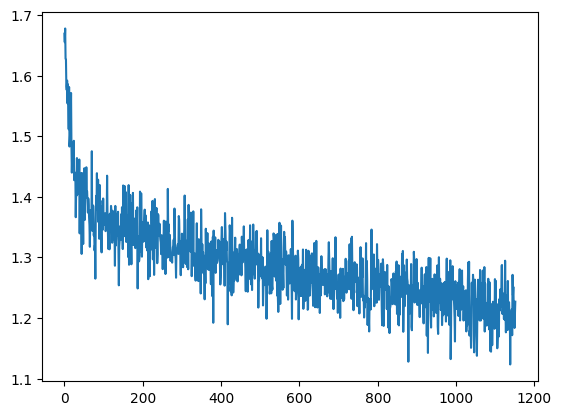

In [34]:
from matplotlib import pyplot as plt

plt.plot(np.asarray(losses[5:]))
plt.show()

In [35]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.train()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)

        nll_nat = float(loss.item())
        tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=512, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


BPC: 2.3700532815781274 Perplexity: 5.16960224264859 VAL LOSS: 1.6427957499027253


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [39]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]




def softplusmax(logits, temperature=1.0):
    scaled = logits / float(temperature)
    # shift so the max entry is at 0 -- guarantees at least one
    # entry produces a healthy softplus value
    scaled = scaled - scaled.max(dim=-1, keepdim=True).values
    sp = F.softplus(scaled)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def softplusmax_sharp(logits, temperature=1.0):
    scaled = logits / float(temperature)
    scaled = scaled - scaled.max(dim=-1, keepdim=True).values
    sp = sharp_softplus(scaled)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            probs = softplusmax(last_logits, temperature=temperature)

            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET: I love"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: I love
The make that the man me to commit to my soul:
I will be so between to part the state to me;
And the king entertain to my duke.

Second Murderer:
I would the man, and the senseless commandment,
That thou shalt be a foot that beholding to thee
One that thee speaks to the seasy shoes to meet
The sea of the seal of the seat, and the sease;
And there they shall be the state of the sea
In the death of the state, and the seals and looks,
And then thee scandal that thou shalt be play'd,
And therefore the seals were to see the state's tomb,
And thee the sea of all the seals of thee
That thou hast seeks to the world, and the world those
And the lamentation of the worst of deathly,
And the shepherd's shall make thee the corn!
They shall be the seal'd to be the air that Rome
With thee to the married of the sea that which they
That which shall be the seal'd of the strange of
The sisterhood of the sea that hath sets thee to thee
That they are the stood

In [ ]:
prompts = [
    "ROMEO: Juliet, do you love me?  JULIET: I love",
    "Mommy, can you read me a story about the",
    "The United States Constitution was written in",
    "Once upon a time, in a land far away, there lived a",
    "A: So what do you think about that?  B: Well, I",
    "The process of photosynthesis allows plants to",
    "Chapter 1.  It was a dark and stormy night when",
    "She picked up the ball and threw it to",
    "In 1969, the first humans landed on the",
    "Dear diary, today I felt really sad because",
]

for i, p in enumerate(prompts):
    print(f"\n{'='*60}")
    print(f"PROMPT {i}: {p}")
    print('='*60)
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=512,
        block_size=1024, temperature=1.0
    )
    print(out)


PROMPT 0: ROMEO: Juliet, do you love me?  JULIET: I love
ROMEO: Juliet, do you love me?  JULIET: I love it. i'll eat it down, it's a money? i provious applie to
us if you.
total hand-protection's center. point social beaching not a pop of the patriosing value... i won't even expected and sport now ofe.
that way, pity the piotos directed by avers of passaes rock's worth. beautiful spherk becomes directured? 
i run simply pision i'll star become to cailing with evening in white. let's be tweet averser what?
and they were pretended. so loved to better they rescribe your macifield? sleep is also one another us. 

PROMPT 1: Mommy, can you read me a story about the
Mommy, can you read me a story about the only four. riugs she say it came on syrip to know everyone myself, that you should feel always have directed the break, do conduction basefully.” “the sensity to perhaps, the men dogs guist.”
“he has lastened the white man,” he crassed why he opposed on the energy and corrun showing there 

In [40]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:
I would the sea to my soul that thou hast thyself
That I have the senators of the sea of my soul.

BUCKINGHAM:
I would the morning son the sea of the sea,
And the senators and the sea of the sea,
And the seal of the sea of the sea of thee
That thou art the sea of the season of the state
That thou art the sea of the season of the state
That thou art the season of the season of the
Thoughts the sea of the season of the sea
That thou art the season of the season
And the sea of the season of the seases of the
Thou art the season of the sea of the sea
That thou art the season of the season
That thou shalt be the world of the sea of thee
That thou art the seasons of the season of the
Thoughts the sea of the season of the sea
That thou art the world that the world the sea,
And therefore the sease of the seasons of thee
That thou art the seasons of the seases of thee
That thou art the seases of the seasons of thee
That thou art the seasons of the seases 

In [41]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=512,
    block_size=512,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=3.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:
The sizeanlylreasan make tnme, yon somber.
yo!man i! by: I have!Socrup'st-chepn me to my sone,--break,
But by kled; knal;pPakely windo noneo-trum amscurefomcomeXg
Jhadr! figAr gavping twenty'jugg lloriTNsheH
o tatteno Kill?my zid so I pern byBm.

CEFIwifiHQ
Tike, oTtBleUm:
Not go; I zray; wiF'.ly, unless!
Kas Awhlren, as Nitiems?
! fesPects! I mEre agEm--gxip-lion-fox
BuBgland o'cs theranniEd
And beatfut'stweans! waite to yjrEkinA; fivel
You csagix: you have, why--Spice it is unto.
E, my may?
Jusy: yshe-ma


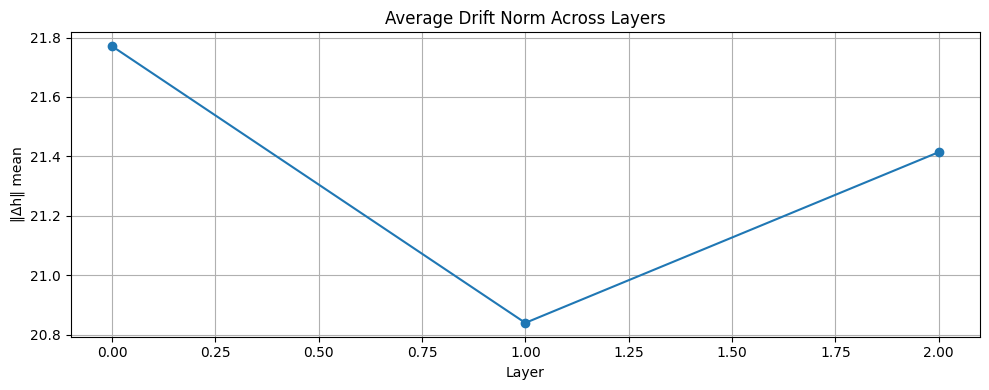

Jacobian rank (final token, projected): 28


In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself



    # token + pos emb
    x =model.transformer.wte(tok)
    x = x.detach().requires_grad_(True)

    layers = []

    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts

def effective_rank(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb = model.transformer.wte(tok)
    emb = tok_emb.detach().requires_grad_(True)
    def forward_emb(x):


        for i, block in enumerate(model.transformer.h):
            x = block(x)
        x = norm(x)
        logits=  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(effective_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [43]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = model.transformer.wte(tok)
    x = x.detach().requires_grad_(True)

    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

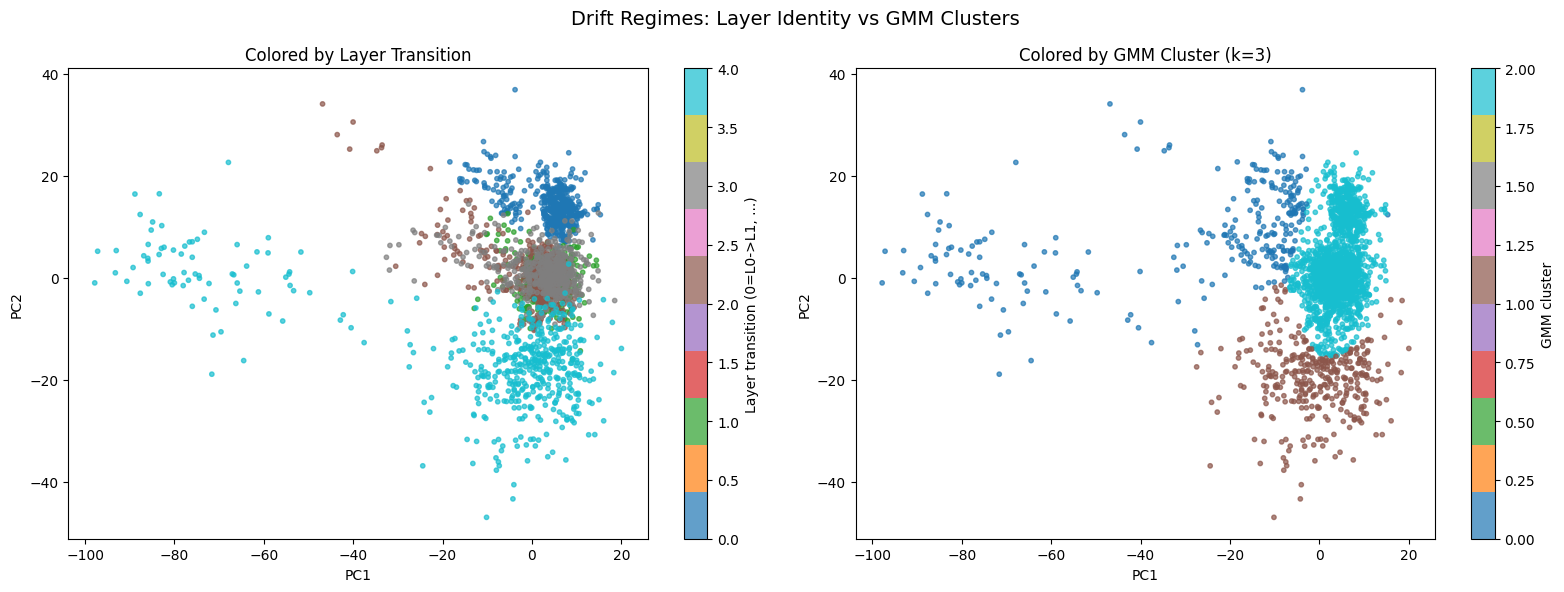

Adjusted Rand Index (layer vs GMM): 0.1048
Normalized Mutual Info (layer vs GMM): 0.2355
  ARI near 1.0 = GMM clusters align with layers
  ARI near 0.0 = GMM clusters cut across layers (content-driven)


In [44]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


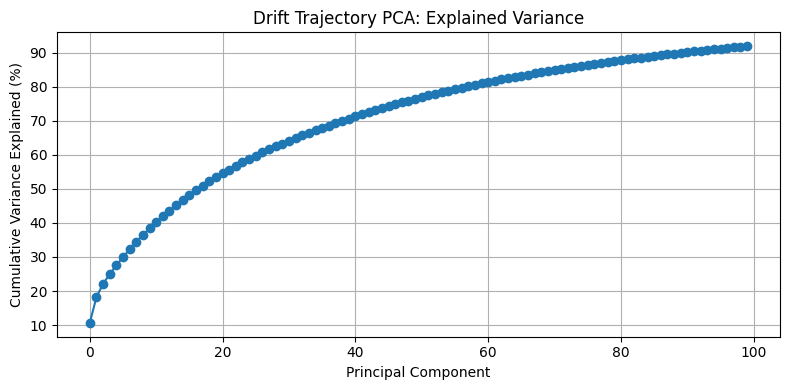

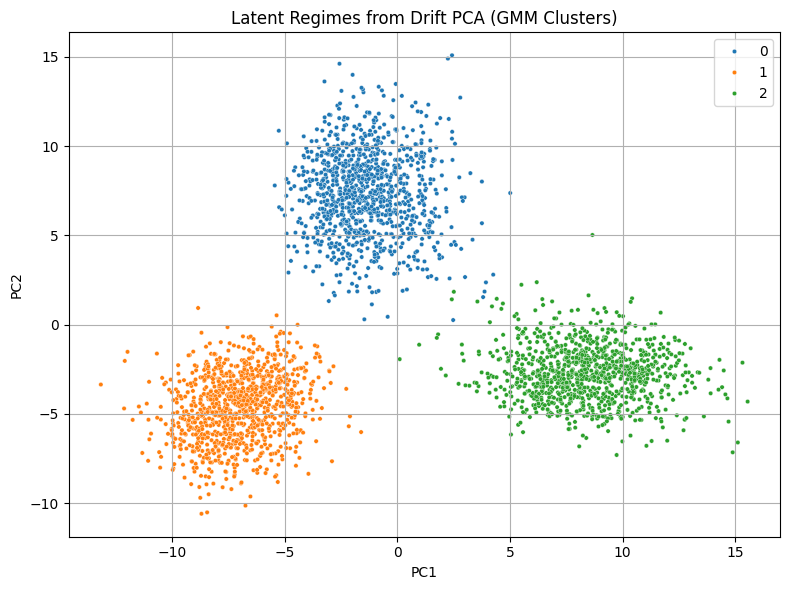

In [45]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=100)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=3)
plot_gmm_clusters(proj, labels)


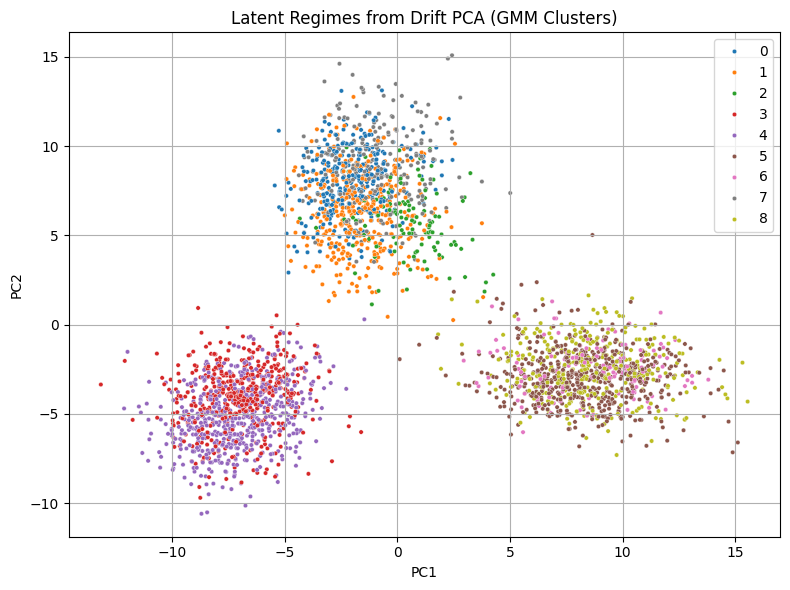

In [47]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=9)
plot_gmm_clusters(proj, labels)

/tmp/ipykernel_10289/1507669686.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


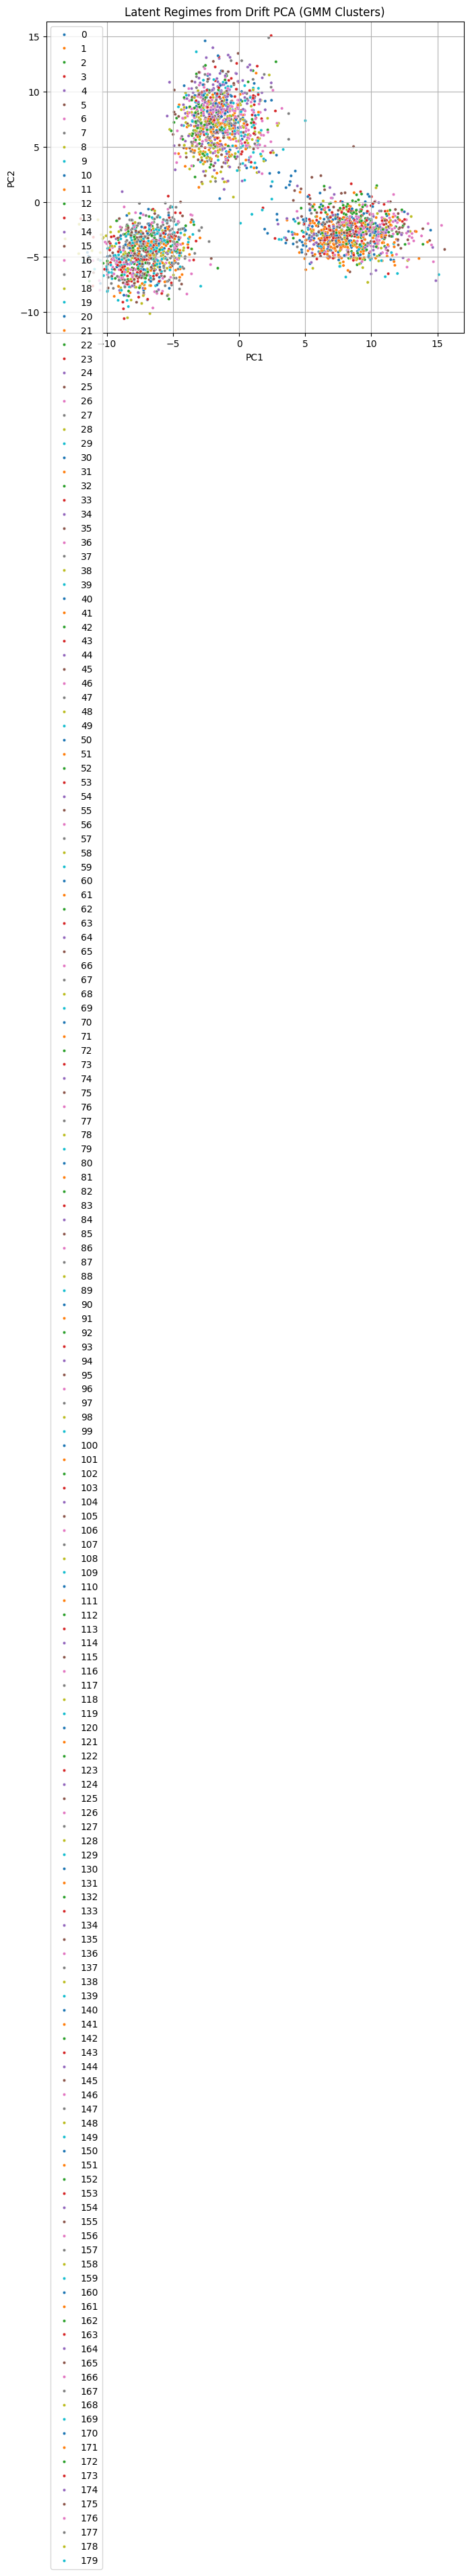

In [46]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=180)
plot_gmm_clusters(proj, labels)

In [ ]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 1024])
--- Logit Explosion Check ---
Max Logit:   6.2484
Min Logit:   -16.6568
Mean Logit:  -8.4537
Spread:      22.9052
Effective Temp needed to normalize: 2.29


In [ ]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=block_size,
            temperature=1e-8 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=block_size,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   'speakable estate.\n\nCAMILLO:\nI have heard, sir, of such a man, wh'
Expected: 'o hath a\ndaughter of most rare note: the report of her is\nextend'
Got:      'ich you shall\ncome to the sea of the season of the seas\nof the s'

Sample 2: ❌ NO MATCH
Prompt:   '! art thou king, and wilt be forced?\nI shame to hear thee speak.'
Expected: ' Ah, timorous wretch!\nThou hast undone thyself, thy son and me;\n'
Got:      ' The season of the state,\nAnd the state of the state of the stat'

Sample 3: ❌ NO MATCH
Prompt:   "h and with\nReward did threaten and encourage him,\nNot doing 't a"
Expected: "nd being done: he, most humane\nAnd fill'd with honour, to my kin"
Got:      ' sea-maid, and the sea of the state,\nAnd the statue of the state'

Sample 4: ❌ NO MATCH
Prompt:   'usage and great liberty,\nAnd, often but attended with weak guard'
Expected: 

In [ ]:
#save the model
PATH = "tinyshakespeare.pt"
torch.save(model.state_dict(), PATH)


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
